<a href="https://colab.research.google.com/github/gabriellbragaa/Computer_Vision_Projs/blob/main/resolu%C3%A7%C3%A3o05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Utilize uma câmera para capturar duas fotos de um mesmo local mas obtidas a partir de
ângulos ligeiramente diferentes.
Para cada um dos descritores mostrados no artigo abaixo, monte uma imagem panorâmica
composta pelas duas imagens capturadas.
Artigo:
S. A. K. Tareen and Z. Saleem, "A comparative analysis of SIFT, SURF, KAZE, AKAZE, ORB, and
BRISK," 2018 International Conference on Computing, Mathematics and Engineering
Technologies (iCoMET), 2018, pp. 1-10, doi: 10.1109/ICOMET.2018.8346440.
Link para o artigo:
https://www.researchgate.net/publication/
323561586_A_comparative_analysis_of_SIFT_SURF_KAZE_AKAZE_ORB_and_BRISK
Alguns links úteis:
https://pyimagesearch.com/2016/01/11/opencv-panorama-stitching/
https://towardsdatascience.com/image-panorama-stitching-with-opencv-2402bde6b46c
https://docs.opencv.org/4.x/d8/d19/tutorial_stitcher.html
https://www.youtube.com/watch?v=8oFRmdDum5k

# Task
Desenvolver um algoritmo em Python para costurar duas imagens e gerar uma imagem panorâmica, permitindo o upload das imagens e utilizando diferentes descritores de características (SIFT, SURF, KAZE, AKAZE, ORB, BRISK) para comparação.

In [1]:
%pip install opencv-python opencv-contrib-python

## Image upload

### Subtask:
Create code to allow the user to upload the two images for stitching.


**Reasoning**:
Import the necessary module for file uploads in Google Colab and create widgets for the user to upload the two images.



In [2]:
from google.colab import files

print("Please upload the first image:")
uploaded1 = files.upload()

print("Please upload the second image:")
uploaded2 = files.upload()

print("Image uploads complete.")

Please upload the first image:


Saving machu_picchu2.jpg to machu_picchu2.jpg
Please upload the second image:


Saving machu_picchu1.jpg to machu_picchu1.jpg
Image uploads complete.


**SHAPE** refere-se as dimensões da imagem. Abaixo, descobrimos qual os shape das duas imagens. Dada, a **ALTURA** ( numero de linhas Pixels na imagem ) , a **LARGURA** ( numero de colunas Pixels na imagem ), e os **CANAIS** ( numero de canais cor na imagem, como RGB ).  

In [10]:
import cv2
import numpy as np

image1_name = list(uploaded1.keys())[0]
image1_data = uploaded1[image1_name]
image1 = cv2.imdecode(np.frombuffer(image1_data, np.uint8), cv2.IMREAD_COLOR)

image2_name = list(uploaded2.keys())[0]
image2_data = uploaded2[image2_name]
image2 = cv2.imdecode(np.frombuffer(image2_data, np.uint8), cv2.IMREAD_COLOR)

print("Shape da First image:", image1.shape)
print("Shape da Second image:", image2.shape)
print("( Altura, Largura, e Canais) ")

First image: (683, 1024, 3)
Second image: (450, 698, 3)
( Altura, Largura, e Canais) 


Agora iremos analisar os pontos de interesse: Keypoints e descrever as caracteristicas.

In [17]:
import cv2
import numpy as np
import pandas as pd

def detect_and_describe(image, descriptor_type):

    detector = None
    if descriptor_type == 'SIFT':
        detector = cv2.SIFT_create()
    elif descriptor_type == 'SURF':
        # SURF is in opencv-contrib-python, need to check if available
        if hasattr(cv2.xfeatures2d, 'SURF_create'):
            detector = cv2.xfeatures2d.SURF_create()
        else:
            print(f"SURF not available in this OpenCV build.")
            return None, None
    elif descriptor_type == 'KAZE':
        detector = cv2.KAZE_create()
    elif descriptor_type == 'AKAZE':
        detector = cv2.AKAZE_create()
    elif descriptor_type == 'ORB':
        detector = cv2.ORB_create()
    elif descriptor_type == 'BRISK':
        detector = cv2.BRISK_create()
    else:
        print(f"Unknown descriptor type: {descriptor_type}")
        return None, None

    if detector is None:
        return None, None

    try:
        keypoints, descriptors = detector.detectAndCompute(image, None)
        return keypoints, descriptors
    except Exception as e:
        print(f"Error detecting/computing features with {descriptor_type}: {e}")
        return None, None

descriptor_types = ['SIFT', 'SURF', 'KAZE', 'AKAZE', 'ORB', 'BRISK']
feature_data = {}
## inicializar um dicionário vazio para armazenar os keypoints

for desc_type in descriptor_types:
    print(f"Processando com {desc_type}...\n")
    kp1, des1 = detect_and_describe(image1, desc_type)
    kp2, des2 = detect_and_describe(image2, desc_type)
    feature_data[desc_type] = (kp1, des1, kp2, des2)
    if kp1 is not None and kp2 is not None:
        print(f"{desc_type}: Encontrados {len(kp1)} keypoints na imagem 1 e {len(kp2)} keypoints na imagem 2.")
    else:
         print(f"{desc_type}: Não detectamos keypoints ou descritores.\n")

# Prepare data for the table
table_data = []
for desc_type, data in feature_data.items():
    kp1, des1, kp2, des2 = data
    row = {
        'Descriptor': desc_type,
        'Image 1 Keypoints': len(kp1) if kp1 is not None else 0,
        'Image 1 Descriptors Shape': des1.shape if des1 is not None else 'N/A',
        'Image 2 Keypoints': len(kp2) if kp2 is not None else 0,
        'Image 2 Descriptors Shape': des2.shape if des2 is not None else 'N/A'
    }
    table_data.append(row)

# Create and display the pandas DataFrame
feature_df = pd.DataFrame(table_data)
print("\nTabela de Dados de Características Armazenados:")
display(feature_df)

Processando com SIFT...

SIFT: Encontrados 8612 keypoints na imagem 1 e 2722 keypoints na imagem 2.
Processando com SURF...

SURF not available in this OpenCV build.
SURF not available in this OpenCV build.
SURF: Não detectamos keypoints ou descritores.

Processando com KAZE...

KAZE: Encontrados 5589 keypoints na imagem 1 e 2598 keypoints na imagem 2.
Processando com AKAZE...

AKAZE: Encontrados 4891 keypoints na imagem 1 e 1847 keypoints na imagem 2.
Processando com ORB...

ORB: Encontrados 500 keypoints na imagem 1 e 500 keypoints na imagem 2.
Processando com BRISK...

BRISK: Encontrados 21858 keypoints na imagem 1 e 7335 keypoints na imagem 2.

Tabela de Dados de Características Armazenados:


,Descriptor,Image 1 Keypoints,Image 1 Descriptors Shape,Image 2 Keypoints,Image 2 Descriptors Shape
0,SIFT,8612,"(8612, 128)",2722,"(2722, 128)"
1,SURF,0,N/A,0,N/A
2,KAZE,5589,"(5589, 64)",2598,"(2598, 64)"
3,AKAZE,4891,"(4891, 61)",1847,"(1847, 61)"
4,ORB,500,"(500, 32)",500,"(500, 32)"
5,BRISK,21858,"(21858, 64)",7335,"(7335, 64)"


"**Matches**" referem-se aos pares de pontos de interesse (keypoints) que foram encontrados em ambas as imagens e que representam a mesma característica ou ponto físico no cenário real.

In [24]:
import cv2
import numpy as np
import pandas as pd

def match_features(des1, des2, descriptor_type, ratio_thresh=0.75):

    if des1 is None or des2 is None:
        return []

    # Choose matcher based on descriptor type
    if descriptor_type in ['ORB', 'BRISK', 'AKAZE']:
        # Binary descriptors
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    elif descriptor_type in ['SIFT', 'SURF', 'KAZE']:
        # Floating-point descriptors
        matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    else:
        print(f"Tipo de descritor desconhecido para correspondência: {descriptor_type}")

        return []

    # Perform KNN matching
    matches = matcher.knnMatch(des1, des2, k=2)

    # Apply ratio test
    good_matches = []
    for m, n in matches:
        if m.distance < ratio_thresh * n.distance:
            good_matches.append(m)

    return good_matches

# Iterate through the feature_data and perform matching
matches_data = {}
for desc_type, data in feature_data.items():
    kp1, des1, kp2, des2 = data
    print(f"\n\nCombinando características para {desc_type}...")
    good_matches = match_features(des1, des2, desc_type)
    matches_data[desc_type] = good_matches
    print(f"{desc_type}: Encontrados {len(good_matches)} bons matches.")

# Prepare data for the table
table_data = []
for desc_type, matches in matches_data.items():
    row = {
        'Descriptor': desc_type,
        'Bons Matches': len(matches)
    }
    table_data.append(row)

# Create and display the pandas DataFrame
matches_df = pd.DataFrame(table_data)
print("\nTabela de Dados de Correspondência (Matches) Armazenados:")
display(matches_df)




Combinando características para SIFT...
SIFT: Encontrados 101 bons matches.


Combinando características para SURF...
SURF: Encontrados 0 bons matches.


Combinando características para KAZE...
KAZE: Encontrados 49 bons matches.


Combinando características para AKAZE...
AKAZE: Encontrados 31 bons matches.


Combinando características para ORB...
ORB: Encontrados 5 bons matches.


Combinando características para BRISK...
BRISK: Encontrados 57 bons matches.

Tabela de Dados de Correspondência (Matches) Armazenados:


,Descriptor,Number of Good Matches
0,SIFT,101
1,SURF,0
2,KAZE,49
3,AKAZE,31
4,ORB,5
5,BRISK,57


In [27]:
import cv2
import numpy as np

def estimate_homography(good_matches, kp1, kp2, min_matches=4):

    if len(good_matches) < min_matches:
        print(f"\nNão há bons matches suficientes ({len(good_matches)}) para estimar a homografia.\n")
        return None, None

    # Extract location of good matches
    points1 = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    points2 = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Estimate RANSAC
    H, mask = cv2.findHomography(points1, points2, cv2.RANSAC, 5.0)

    return H, mask

homography_data = {}
for desc_type, good_matches in matches_data.items():
    print(f"\nEstimando homografia para {desc_type}...")


    kp1, _, kp2, _ = feature_data[desc_type]

    H, mask = estimate_homography(good_matches, kp1, kp2)

    homography_data[desc_type] = (H, mask)

    if H is not None:
        print(f"{desc_type}: Homografia estimada com sucesso com {np.sum(mask)} inliers de {len(good_matches)} matches.")
    else:
        print(f"{desc_type}: Não foi possível estimar a homografia.")


# Display a sample of the stored homography data
print("\nAmostra de dados de homografia armazenados:\n")

for desc_type, data in homography_data.items():
    H, mask = data
    print(f"\n{desc_type}:")
    print(f"  Matriz de Homografia: {'Presente' if H is not None else 'Nenhuma'}, Shape: {H.shape if H is not None else 'N/A'}")
    print(f"  Máscara: {'Presente' if mask is not None else 'Nenhuma'}, Shape: {mask.shape if mask is not None else 'N/A'}")



Estimando homografia para SIFT...
SIFT: Homografia estimada com sucesso com 27 inliers de 101 matches.

Estimando homografia para SURF...

Não há bons matches suficientes (0) para estimar a homografia.

SURF: Não foi possível estimar a homografia.

Estimando homografia para KAZE...
KAZE: Homografia estimada com sucesso com 22 inliers de 49 matches.

Estimando homografia para AKAZE...
AKAZE: Homografia estimada com sucesso com 7 inliers de 31 matches.

Estimando homografia para ORB...
ORB: Homografia estimada com sucesso com 4 inliers de 5 matches.

Estimando homografia para BRISK...
BRISK: Homografia estimada com sucesso com 19 inliers de 57 matches.

Amostra de dados de homografia armazenados:


SIFT:
  Matriz de Homografia: Presente, Shape: (3, 3)
  Máscara: Presente, Shape: (101, 1)

SURF:
  Matriz de Homografia: Nenhuma, Shape: N/A
  Máscara: Nenhuma, Shape: N/A

KAZE:
  Matriz de Homografia: Presente, Shape: (3, 3)
  Máscara: Presente, Shape: (49, 1)

AKAZE:
  Matriz de Homografi

Agora, iremos **aplicar a homografia** encontrada para "deformar" uma das imagens, e em seguida, combina-la com outra imagem para criar a panorâmica final.

In [31]:
import cv2
import numpy as np

def warp_and_stitch(image1, image2, H, image1_shape):

    if H is None:
        return None

    h1, w1 = image1_shape[:2]
    h2, w2 = image2.shape[:2]


    corners1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)


    transformed_corners = cv2.perspectiveTransform(corners1, H)


    min_x = np.min(transformed_corners[:, :, 0])
    max_x = np.max(transformed_corners[:, :, 0])
    min_y = np.min(transformed_corners[:, :, 1])
    max_y = np.max(transformed_corners[:, :, 1])


    panorama_width = int(max(w2, max_x) - min(0, min_x))
    panorama_height = int(max(h2, max_y) - min(0, min_y))



    translate_x = -min(0, min_x)
    translate_y = -min(0, min_y)
    translation_matrix = np.array([[1, 0, translate_x],
                                   [0, 1, translate_y],
                                   [0, 0, 1]], dtype=np.float32)

    H_translated = translation_matrix @ H

    warped_image1 = cv2.warpPerspective(image1, H_translated, (panorama_width, panorama_height))


    panorama = np.zeros((panorama_height, panorama_width, 3), dtype=np.uint8)


    panorama[int(translate_y):int(translate_y)+h2, int(translate_x):int(translate_x)+w2] = image2

    mask = warped_image1 > 0
    panorama[mask] = warped_image1[mask]


    return panorama

panoramas = {}

for desc_type, data in homography_data.items():
    H, mask = data
    print(f"Tentando costurar a panorâmica para {desc_type}...")
    if H is not None:

        panorama = warp_and_stitch(image1, image2, H, image1.shape)
        if panorama is not None:
            panoramas[desc_type] = panorama
            print(f"Panorâmica costurada com sucesso para {desc_type}.\n")

        else:
            print(f"A costura falhou para {desc_type}.")
    else:
        print(f"Pulando a costura para {desc_type} devido à falta de homografia.\n")


print("\nPanorâmicas geradas:\n")
for desc_type, pano in panoramas.items():
    print(f"{desc_type}: Shape {pano.shape}")


Tentando costurar a panorâmica para SIFT...
Panorâmica costurada com sucesso para SIFT.

Tentando costurar a panorâmica para SURF...
Pulando a costura para SURF devido à falta de homografia.

Tentando costurar a panorâmica para KAZE...
Panorâmica costurada com sucesso para KAZE.

Tentando costurar a panorâmica para AKAZE...
Panorâmica costurada com sucesso para AKAZE.

Tentando costurar a panorâmica para ORB...
Panorâmica costurada com sucesso para ORB.

Tentando costurar a panorâmica para BRISK...
Panorâmica costurada com sucesso para BRISK.


Panorâmicas geradas:

SIFT: Shape (688, 1020, 3)
KAZE: Shape (584, 955, 3)
AKAZE: Shape (3515, 1363, 3)
ORB: Shape (453, 698, 3)
BRISK: Shape (1779, 2320, 3)




Panorama para SIFT:


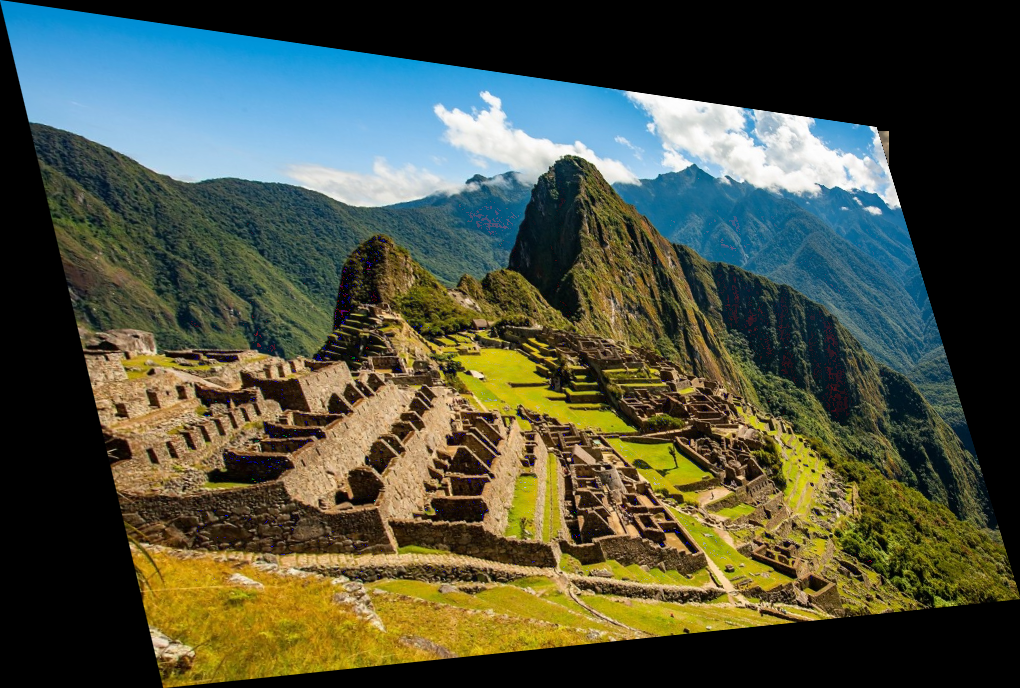



Panorama para KAZE:


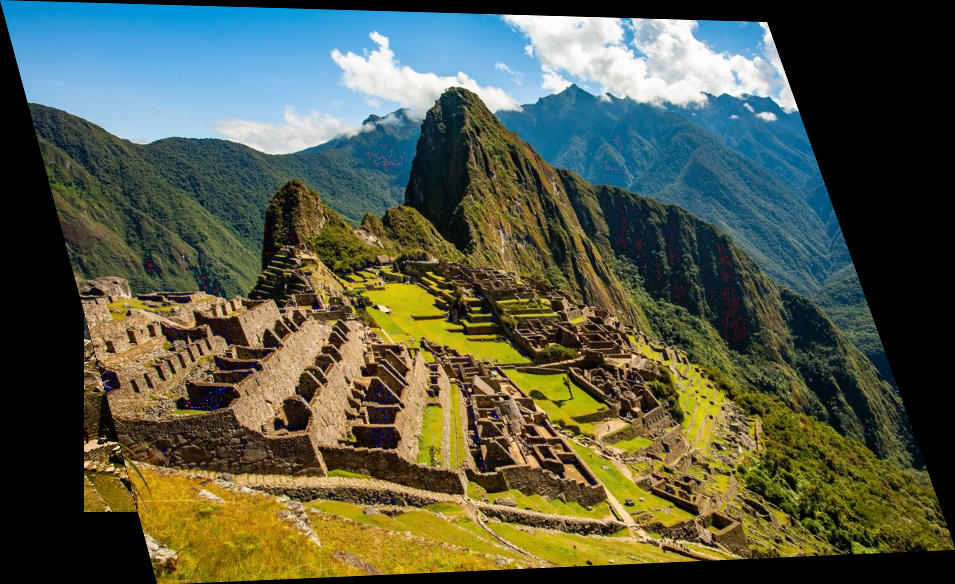



Panorama para AKAZE:


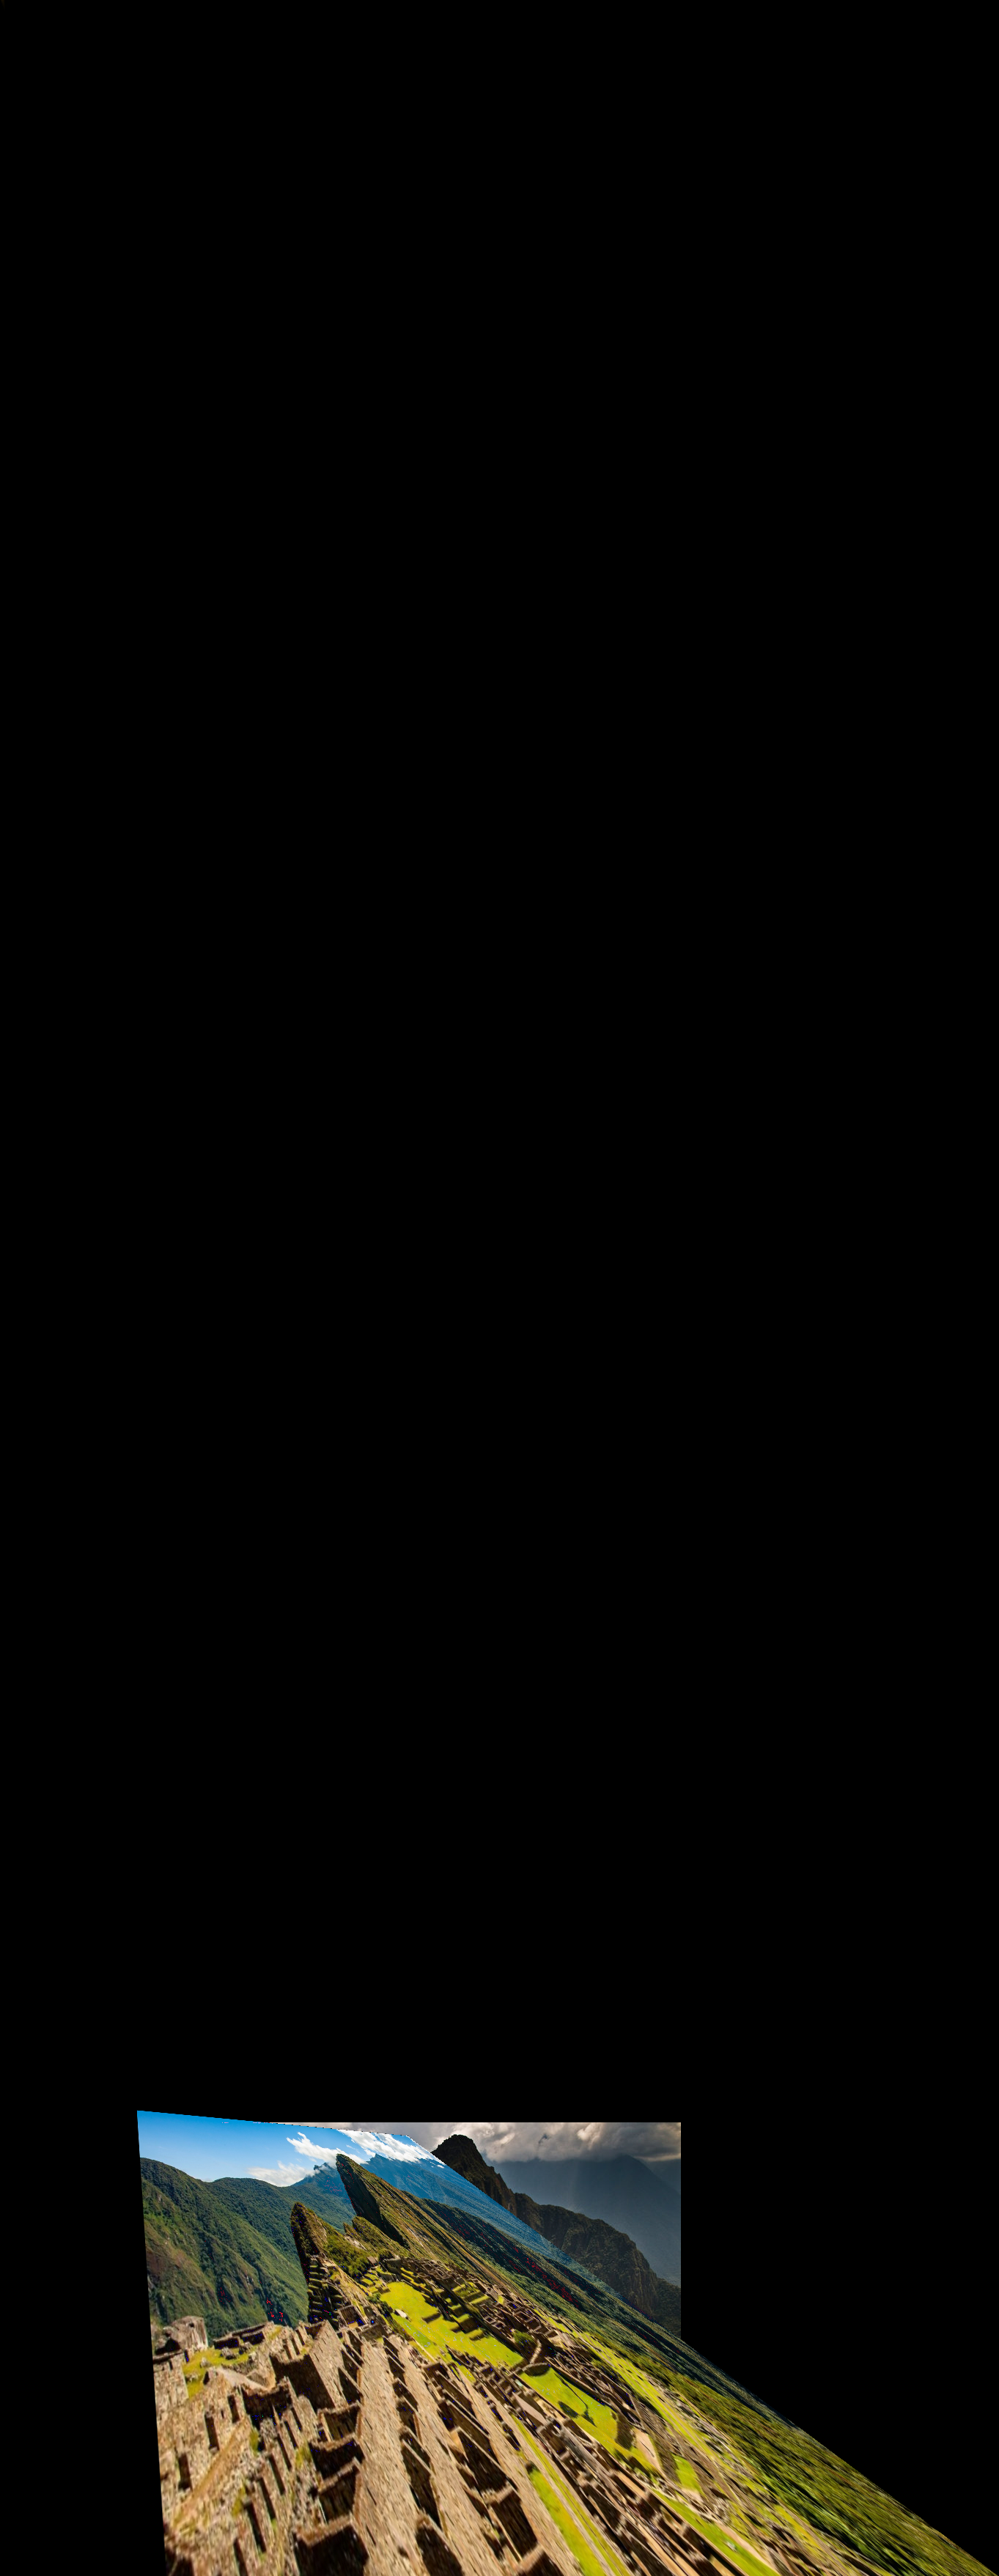



Panorama para ORB:


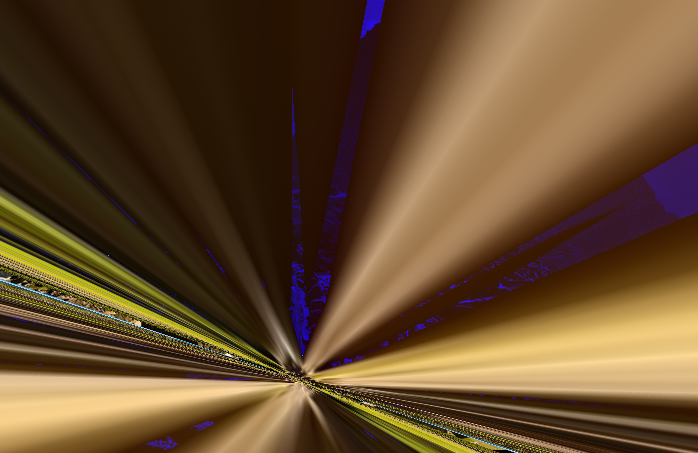



Panorama para BRISK:


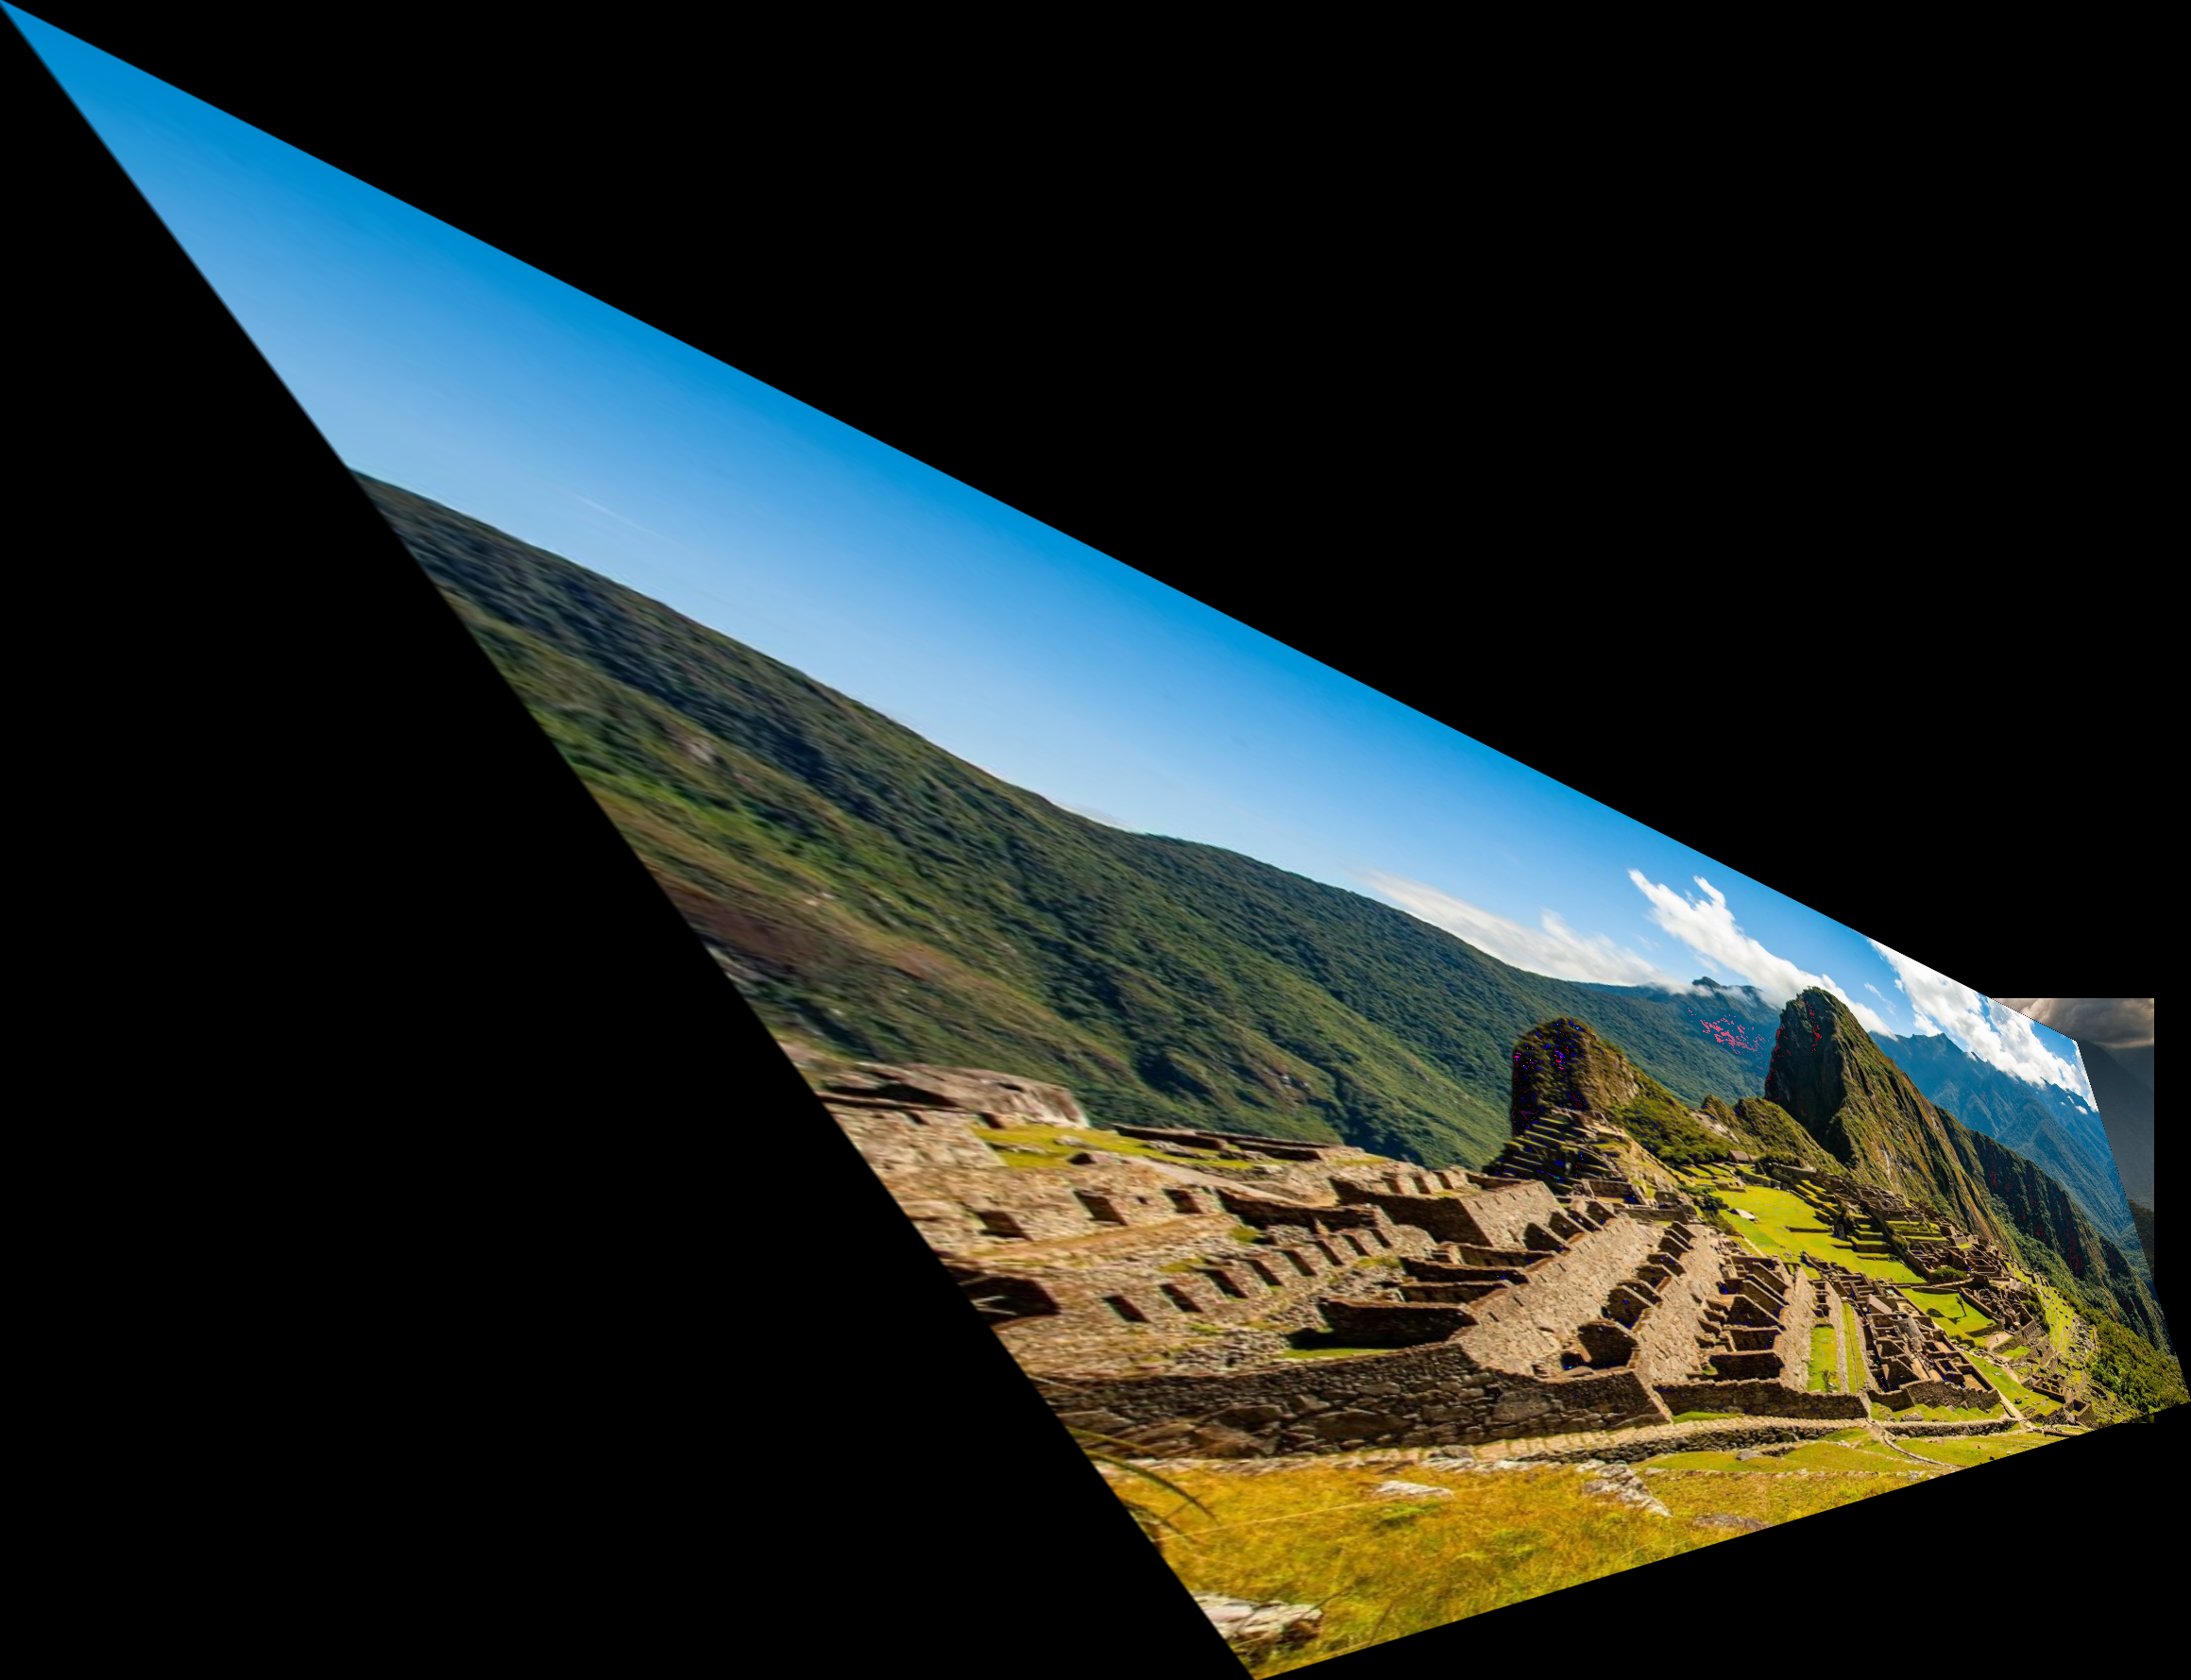

In [33]:
from google.colab.patches import cv2_imshow


for desc_type, panorama in panoramas.items():
    print(f"\n\nPanorama para {desc_type}:")

    cv2_imshow(panorama)
